# EtherCAT带练：PDO、状态机与周期时间线

配套：[EtherCAT连续带练](../engineering/05_ethercat.md#worked-lessons)。本Notebook不安装主站、不操作网口、不写SDO/PDO；它用字节和状态记录解释工位调试前必须弄清的约定。真实ESI、映射、状态条件和停止流程另按设备确认。


In [1]:
from pathlib import Path
import sys, math, csv, json

# Locate the course even when the kernel starts in notebooks/.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "labs" / "course_lab.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the complete trainning_materials folder.")
sys.path.insert(0, str(ROOT / "labs"))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image, HTML
import ipywidgets as widgets
from course_lab import fk, ik, encode_frame, decode_frame, feedback_fresh, sphere_gap, fit_line, mse
from algorithm_lab import jacobian, numerical_ik, astar, trapezoid, kalman_step, pid_demo
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})
print("Python:", sys.executable)
print("Course:", ROOT.name)


Python: D:\code_agent\trainning_materials\.venv\Scripts\python.exe
Course: trainning_materials


In [2]:
import struct
import ctypes
from workshop_lab import drive_decision
from engineering_lab import decode_teaching_pdo, cia402_state, process_input, timing_report


## 1. 计算过程映像的偏移
教学输出依次为16位控制字、32位目标位置、8位模式，共7字节。先写偏移0、2、6，再运行。与本机C结构体对齐规则比较，理解为什么不能直接猜offset。


In [3]:
output = struct.pack("<Hib", 0x000F, 1000, 8)
print("packed:", output.hex(" "), "bytes:", len(output))
assert output == bytes.fromhex("0f 00 e8 03 00 00 08")
class NativeLayout(ctypes.Structure):
    _fields_ = [("control", ctypes.c_uint16), ("position", ctypes.c_int32), ("mode", ctypes.c_int8)]
print("native offsets:", NativeLayout.control.offset, NativeLayout.position.offset, NativeLayout.mode.offset)
print("native size:", ctypes.sizeof(NativeLayout), "(platform dependent)")


packed: 0f 00 e8 03 00 00 08 bytes: 7
native offsets: 0 4 8
native size: 12 (platform dependent)


## 2. 独立解码有符号反馈
输入映射与输出是两块不同的数据。当前输入只包含16位状态字和32位位置，长度6。不要给它套刚才7字节输出布局。


In [4]:
raw = bytes.fromhex("27 00 18 fc ff ff")
decoded = decode_teaching_pdo(raw)
print(decoded)
print("same position read unsigned:", int.from_bytes(raw[2:], "little", signed=False))
assert decoded["position_counts"] == -1000
try:
    decode_teaching_pdo(raw + b"\x00\x00")
except ValueError as error:
    print("changed layout rejected:", error)


{'statusword': 39, 'drive_state': 'operation_enabled', 'position_counts': -1000}
same position read unsigned: 4294966296
changed layout rejected: Teaching PDO must contain exactly 6 bytes


## 3. 状态掩码与附加位
先猜0x0027和0x1227是否都能识别为Operation enabled。对主状态用掩码，对其他诊断位另行解析。状态识别不证明当前模式、位置单位或安全条件正确。


In [5]:
for word in (0x0040, 0x0021, 0x0023, 0x0027, 0x1227, 0x0008):
    print(f"0x{word:04x}", cia402_state(word))
assert cia402_state(0x0027) == cia402_state(0x1227)


0x0040 switch_on_disabled
0x0021 ready_to_switch_on
0x0023 switched_on
0x0027 operation_enabled
0x1227 operation_enabled
0x0008 fault


## 4. 总线OP只是多个门禁之一
同一张决策表同时输入总线状态、驱动状态、数据有效性、模式、目标对齐和开始请求。下方函数只输出建议字符串，没有写硬件的能力。逐行解释它为什么允许或阻止推进。
这里target_aligned表示启动时已完成目标初始化的记录，不要求运动中目标始终等于反馈。已使能时丢失模式或总线条件将进入停止策略，而非继续等待并输出运动。


In [6]:
scenarios = [
    ("PREOP", 0x0040, True, True, True, True),
    ("OP", 0x0040, True, False, True, True),
    ("OP", 0x0040, True, True, False, True),
    ("OP", 0x0040, True, True, True, True),
    ("OP", 0x0021, True, True, True, True),
    ("OP", 0x0023, True, True, True, True),
    ("OP", 0x0027, True, True, True, True),
    ("OP", 0x0027, False, True, True, True),
    ("OP", 0x0008, True, True, True, True),
    ("OP", 0x0027, True, True, True, False),
]
decisions = []
for arguments in scenarios:
    action = drive_decision(*arguments)
    decisions.append({"arguments": arguments, "decision": action})
    print(arguments, "=>", action)
assert decisions[6]["decision"] == "allow_bounded_reference"
assert decisions[7]["decision"] == "stop_policy_invalid_feedback"


('PREOP', 64, True, True, True, True) => wait_bus_configuration
('OP', 64, True, False, True, True) => wait_mode_and_target
('OP', 64, True, True, False, True) => wait_mode_and_target
('OP', 64, True, True, True, True) => request_shutdown_0x0006
('OP', 33, True, True, True, True) => request_switch_on_0x0007
('OP', 35, True, True, True, True) => request_enable_0x000f
('OP', 39, True, True, True, True) => allow_bounded_reference
('OP', 39, False, True, True, True) => stop_policy_invalid_feedback
('OP', 8, True, True, True, True) => diagnose_fault_manual_reset_required
('OP', 39, True, True, True, False) => stop_policy


## 5. WKC不足时不能刷新旧缓存
期望值6是本实验给定的配置假设，不代表6个从站。比较实际6和4时的返回，确认无效周期没有发布一个貌似新鲜的位置。


In [7]:
for actual in (6, 4):
    print(actual, process_input(raw, actual, 6))
assert process_input(raw, 4, 6)["input"] is None


6 {'valid': True, 'reason': 'exchange_valid_only', 'input': {'statusword': 39, 'drive_state': 'operation_enabled', 'position_counts': -1000}}
4 {'valid': False, 'reason': 'wkc_mismatch', 'input': None}


## 6. 把计划时间和实际计算区间画出来
平均周期1ms仍可能错过某次截止时间。每条浅灰线是计划周期，彩色线是计算区间；红色表示计算结束超出本周期截止。此图没有模拟DC硬件，只说明应用调度需要单独测量。


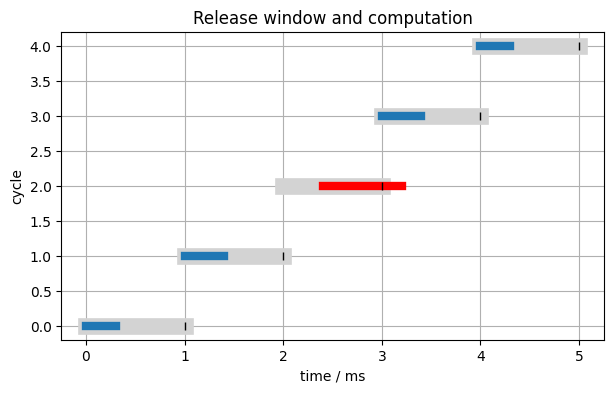

mean interval: 0.001 misses: 1


In [8]:
timing = timing_report([0., .001, .0024, .003, .004], [.0003, .0004, .0008, .0004, .0003], .001)
fig, ax = plt.subplots()
for row in timing["cycles"]:
    k = row["cycle"]
    ax.plot([k, k+1], [k, k], color="lightgray", linewidth=12)
    ax.plot([row["start_s"]*1000, row["finish_s"]*1000], [k, k],
            color="red" if row["missed"] else "tab:blue", linewidth=6)
    ax.plot([k+1], [k], "k|")
ax.set(xlabel="time / ms", ylabel="cycle", title="Release window and computation")
plt.show()
print("mean interval:", timing["mean_interval_s"], "misses:", timing["missed_deadlines"])
assert timing["missed_deadlines"] == 1


## 7. 练习与答案
将第三次计算时间0.8ms改成0.5ms，截止违例应消失，但启动仍迟到0.4ms。修改WKC不能修正这个时间问题。将目标对齐条件改False，即使OP与驱动状态正常，也不能进入有界参考执行。

提交过程映像、状态记录和周期图，注明哪些只是模型假设。实际工位还要核对ESI身份、同步模式、看门狗、抱闸与停止行为。


In [9]:
out = ROOT / "outputs" / "workshop_ethercat.json"
out.parent.mkdir(exist_ok=True)
out.write_text(json.dumps({"scope": "offline PDO/state exercise", "decisions": decisions, "timing": timing},
                          indent=2) + "\n", encoding="utf-8")
print("Saved:", out)


Saved: D:\code_agent\trainning_materials\outputs\workshop_ethercat.json
